# 📚 Dataclasses en Python

**Objetivos de aprendizaje:**

- Comprender el propósito de las dataclasses
- Aprender a crear y usar dataclasses
- Conocer las funcionalidades avanzadas
- Aplicar dataclasses en proyectos reales

Al finalizar esta guía, deberías ser capaz de:

✅ Explicar qué son y para qué sirven las dataclasses

✅ Crear dataclasses con diferentes configuraciones

✅ Usar `field()` para personalizar atributos

✅ Implementar validaciones con `__post_init__`

✅ Convertir dataclasses a diccionarios y tuplas

✅ Decidir cuándo usar dataclasses vs clases tradicionales

✅ Aplicar dataclasses en proyectos reales


---


## 1\. Introducción

En el curso básico de Python, al ver la Programación Orientada a Objetos, hemos visto que crear clases puede ser repetitivo. Las **dataclasses** llegaron en Python 3.7 para hacer nuestra vida más fácil cuando trabajamos con clases que principalmente almacenan datos.

---

## 2\. ¿Qué son las Dataclasses?

Las **dataclasses** son una característica de Python que automatiza la creación de clases diseñadas principalmente para almacenar datos. Proporcionan decoradores y funciones que generan automáticamente métodos especiales como `__init__()`, `__repr__()`, `__eq__()`, entre otros.




In [ ]:
# Sin dataclass
class Producto:
    def __init__(self, nombre: str, precio: float, cantidad: int):
        self.nombre = nombre
        self.precio = precio
        self.cantidad = cantidad
    def __repr__(self):
        return f"Producto(nombre={self.nombre}, precio={self.precio}, cantidad={self.cantidad})"
    def __eq__(self, other):
        """La equidad exige misma clase e igualdad en todos los atributos"""
        if not isinstance(other, Producto):
            return False
        return (self.nombre, self.precio, self.cantidad) == (other.nombre, other.precio, other.cantidad)

In [ ]:
# CON dataclass
from dataclasses import dataclass
@dataclass
class Producto:
    nombre: str
    precio: float
    cantidad: int

¡Mucho más limpio, ¿verdad?!

## 3\. ¿Por qué usar Dataclasses?

### Ventajas principales:

✅ **Menos código boilerplate** (código repetitivo)
✅ **Mayor legibilidad**
✅ **Type hints integrados**
✅ **Métodos automáticos** (`__init__`, `__repr__`, `__eq__`, etc.)
✅ **Inmutabilidad opcional**
✅ **Validación de datos**

### Casos de uso ideales:

- 📦 Clases que principalmente almacenan datos (DTOs - Data Transfer Objects)
- 🗄️ Modelos de datos simples
- 📊 Estructuras para configurar parámetros
- Entidades en juegos o simulaciones


> 💡 un **DTO (Data Transfer Object)** es un objeto simple cuya única responsabilidad es **transportar datos** entre diferentes partes de un sistema (por ejemplo, entre capas de una aplicación o a través de la red).
>
> No contiene lógica de negocio, solo atributos y, opcionalmente, métodos para serializar/deserializar (convertir a JSON, dict, etc.).
>
> Ejemplo:
>
> ```python
> from dataclasses import dataclass
> @dataclass
> class UserDTO:
>     id: int
>     name: str
>     email: str
> # Capa de servicios recibe datos
> user_data = UserDTO(id=1, name="Ana", email="ana@mail.com")
> # Enviar a API o capa de persistencia
> send_to_api(user_data.__dict__)  # convertir a dict para JSON
> ```


---



## 4\. Creación de Dataclasses



### Sintaxis básica




In [ ]:
from dataclasses import dataclass
@dataclass
class Estudiante:
    nombre: str
    edad: int
    carrera: str
    promedio: float = 0.0  # Valor por defecto



### Diagrama: Proceso de creación


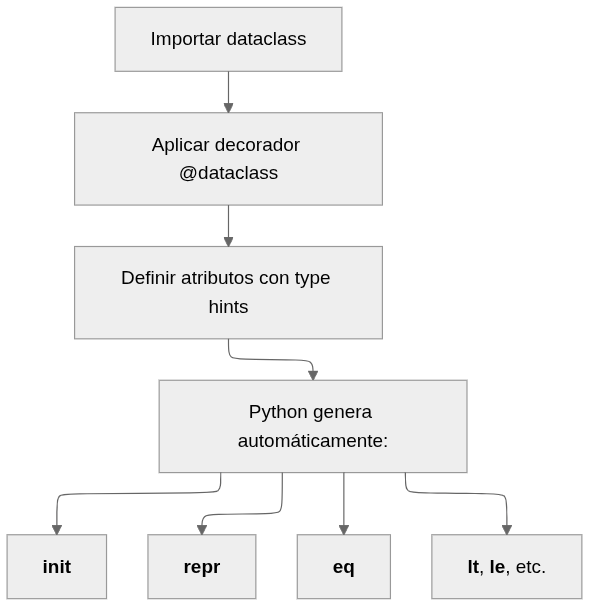




### Ejemplo completo paso a paso




In [ ]:
from dataclasses import dataclass
@dataclass
class Libro:
    """Clase que representa un libro en una biblioteca"""
    titulo: str
    autor: str
    isbn: str
    paginas: int
    disponible: bool = True  # Valor por defecto
    # Puedes agregar métodos personalizados
    def prestar(self):
        if self.disponible:
            self.disponible = False
            return True
        return False
    def devolver(self):
        self.disponible = True
# Uso
libro1 = Libro("Cien años de soledad", "Gabriel García Márquez", "978-0307474728", 417)
print(libro1)
# Output: Libro(titulo='Cien años de soledad', autor='Gabriel García Márquez',
#         isbn='978-0307474728', paginas=417, disponible=True)
libro1.prestar()
print(libro1)  # Acceso a atributos
# Output: Cien años de soledad

Libro(titulo='Cien años de soledad', autor='Gabriel García Márquez', isbn='978-0307474728', paginas=417, disponible=True)
Libro(titulo='Cien años de soledad', autor='Gabriel García Márquez', isbn='978-0307474728', paginas=417, disponible=False)


---
## 5\. Uso y Funcionalidades

### 5.1 Inicialización y creación de instancias




In [ ]:
from dataclasses import dataclass
@dataclass
class Coordenada:
    x: float
    y: float
    z: float = 0.0  # Valor por defecto

# Diferentes formas de crear instancias
c1 = Coordenada(10, 20)           # z toma el valor por defecto (0.0)
c2 = Coordenada(5, 15, 30)        # Todos los valores especificados
c3 = Coordenada(x=1, y=2, z=3)    # Usando argumentos con nombre
print(c1)  # Coordenada(x=10, y=20, z=0.0)
print(c2)  # Coordenada(x=5, y=15, z=30)

Coordenada(x=10, y=20, z=0.0)
Coordenada(x=5, y=15, z=30)




### 5.2 Comparación de instancias




In [ ]:
@dataclass
class Punto:
    x: int
    y: int
p1 = Punto(3, 4)
p2 = Punto(3, 4)
p3 = Punto(5, 6)
print(p1 == p2)  # True (comparación por valor)
print(p1 == p3)  # False
print(p1 != p3)  # True

True
False
True




### 5.3 Conversión a diccionario y tupla




In [ ]:
from dataclasses import dataclass, asdict, astuple
@dataclass
class Persona:
    nombre: str
    edad: int
    email: str

persona = Persona("Ana García", 28, "ana@email.com")
# Convertir a diccionario
dict_persona = asdict(persona)
print(dict_persona)
# {'nombre': 'Ana García', 'edad': 28, 'email': 'ana@email.com'}
# Convertir a tupla
tupla_persona = astuple(persona)
print(tupla_persona)
# ('Ana García', 28, 'ana@email.com')

{'nombre': 'Ana García', 'edad': 28, 'email': 'ana@email.com'}
('Ana García', 28, 'ana@email.com')


### 5.4 Diagrama: Ciclo de vida de una Dataclass

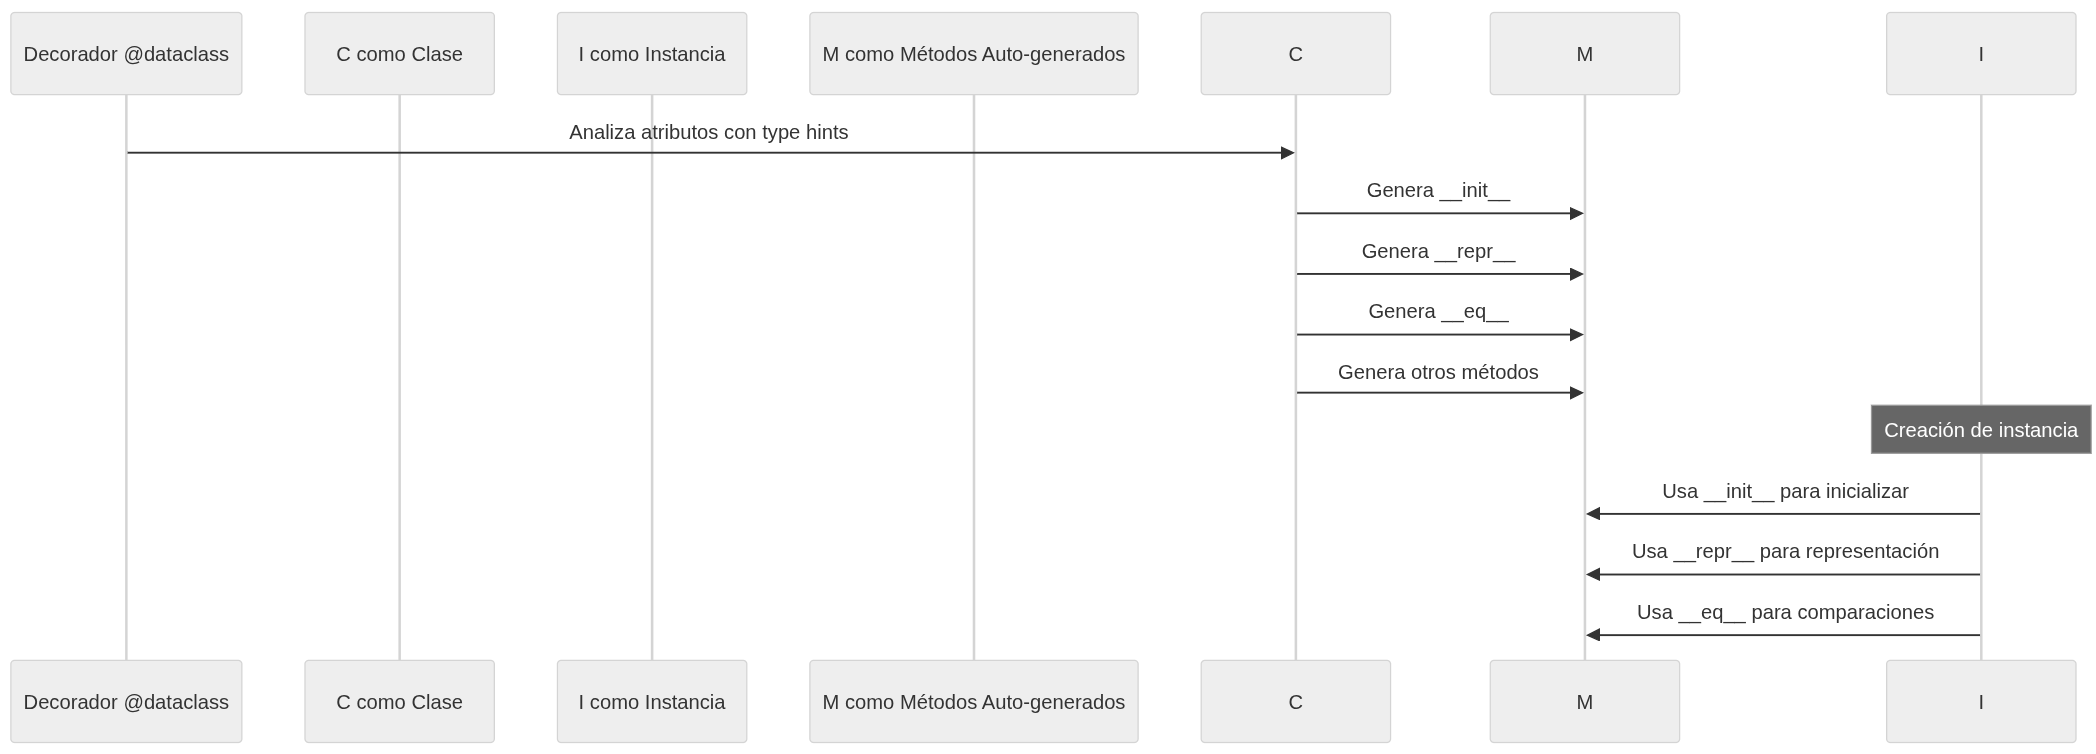




---

## 6\. Características Avanzadas

### 6.1 El decorador con parámetros




In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True, order=True)
class Temperatura:
    """Dataclass inmutable y ordenable"""
    valor: float
    unidad: str = "Celsius"

# frozen=True hace que la instancia sea inmutable
temp = Temperatura(25.5)
# temp.valor = 30  # ❌ Esto lanzaría: FrozenInstanceError

# order=True permite comparaciones <, >, <=, >=
temp1 = Temperatura(20)
temp2 = Temperatura(25)
print(temp1 < temp2)  # True

True


**Parámetros del decorador:**

| Parámetro | Tipo | Descripción |
| --- | --- | --- |
| `init` | bool | Genera `__init__` (default: True) |
| `repr` | bool | Genera `__repr__` (default: True) |
| `eq` | bool | Genera `__eq__` (default: True) |
| `order` | bool | Genera métodos de orden (default: False) |
| `unsafe_hash` | bool | Genera `__hash__` (default: None) |
| `frozen` | bool | Hace la clase inmutable (default: False) |
| `match_args` | bool | Soporte para pattern matching (Python 3.10+) |



### 6.2 La función `field()`

In [ ]:
from dataclasses import dataclass, field
from typing import List

@dataclass
class Curso:
    nombre: str
    estudiantes: List[str] = field(default_factory=list)
    codigo: str = field(default="SIN-CODIGO", repr=False)
    activo: bool = field(default=True, init=False)

    def __post_init__(self):
        # Se ejecuta después de __init__
        self.activo = len(self.estudiantes) > 0
# Uso
curso1 = Curso("Python Avanzado")
curso2 = Curso("Machine Learning", ["Ana", "Carlos", "Diana"])
print(curso1)
print(curso2)
# Curso(nombre='Python Avanzado', estudiantes=[])
# Nota: 'codigo' no aparece por repr=False
print(curso2.estudiantes)
# ['Ana', 'Carlos', 'Diana']

Curso(nombre='Python Avanzado', estudiantes=[], activo=False)
Curso(nombre='Machine Learning', estudiantes=['Ana', 'Carlos', 'Diana'], activo=True)
['Ana', 'Carlos', 'Diana']


**Parámetros de `field()`:**

| Parámetro | Descripción |
| --- | --- |
| `default` | Valor por defecto |
| `default_factory` | Función que crea el valor por defecto |
| `repr` | Incluir en `__repr__` |
| `hash` | Incluir en `__hash__` |
| `init` | Incluir en `__init__` |
| `compare` | Incluir en métodos de comparación |
| `metadata` | Diccionario de metadatos personalizado |

### 6.3 `__post_init__`: Personalización después de la inicialización




In [ ]:
from dataclasses import dataclass
from datetime import datetime
@dataclass
class RegistroUsuario:
    username: str
    email: str
    fecha_registro: datetime = None
    def __post_init__(self):
        # Validación y procesamiento
        if "@" not in self.email:
            raise ValueError("Email inválido")
        if self.fecha_registro is None:
            self.fecha_registro = datetime.now()
        self.username = self.username.lower().strip()
# Uso
usuario = RegistroUsuario("  JuanPerez  ", "juan@email.com")
print(usuario.username)  # "juanperez"
print(usuario.fecha_registro)  # Fecha y hora actual

juanperez
2026-04-30 17:23:00.244875




### 6.4 Dataclasses anidadas




In [ ]:
from dataclasses import dataclass
from typing import List
@dataclass
class Direccion:
    calle: str
    numero: int
    ciudad: str
    codigo_postal: str
@dataclass
class Empleado:
    nombre: str
    id_empleado: int
    direccion: Direccion
    habilidades: List[str]
# Creación
direccion1 = Direccion("Av. Principal", 123, "Madrid", "28001")
empleado1 = Empleado("María López", 1001, direccion1, ["Python", "SQL"])
print(empleado1.direccion.ciudad)  # Madrid
print(empleado1.habilidades)       # ['Python', 'SQL']

Madrid
['Python', 'SQL']


### 6.5 Diagrama: Estructura de una Dataclass avanzada
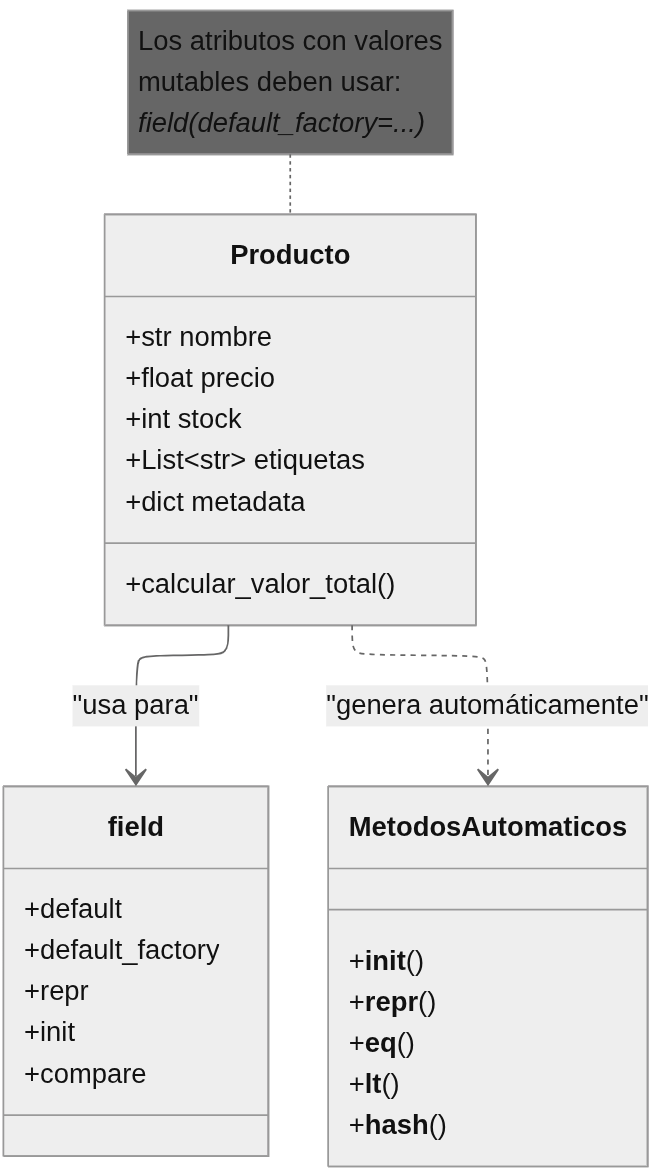

---



## 7\. Comparación: Clases Tradicionales vs Dataclasses

### Ejemplo comparativo completo

In [ ]:
# ========== CLASE TRADICIONAL ==========
class ProductoTradicional:
    def __init__(self, nombre: str, precio: float, stock: int):
        self.nombre = nombre
        self.precio = precio
        self.stock = stock
    def __repr__(self):
        return f"ProductoTradicional(nombre={self.nombre}, precio={self.precio}, stock={self.stock})"
    def __eq__(self, other):
        if not isinstance(other, ProductoTradicional):
            return False
        return (self.nombre, self.precio, self.stock) == (other.nombre, other.precio, other.stock)
    def __hash__(self):
        return hash((self.nombre, self.precio, self.stock))


In [ ]:
# ========== DATACLASS ==========
from dataclasses import dataclass
@dataclass
class ProductoDataclass:
    nombre: str
    precio: float
    stock: int


In [ ]:
# ========== COMPARACIÓN ==========
# Líneas de código:
# Tradicional: ~25 líneas
# Dataclass: ~5 líneas
# Funcionalidad:
p1_trad = ProductoTradicional("Laptop", 1000, 10)
p1_data = ProductoDataclass("Laptop", 1000, 10)
print(p1_trad)  # ProductoTradicional(nombre=Laptop, precio=1000, stock=10)
print(p1_data)  # ProductoDataclass(nombre='Laptop', precio=1000, stock=10)
print(p1_trad == ProductoTradicional("Laptop", 1000, 10))  # True
print(p1_data == ProductoDataclass("Laptop", 1000, 10))    # True
# ¡Misma funcionalidad, 80% menos código!

ProductoTradicional(nombre=Laptop, precio=1000, stock=10)
ProductoDataclass(nombre='Laptop', precio=1000, stock=10)
True
True


### Tabla comparativa

| Característica | Clase Tradicional | Dataclass |
| --- | --- | --- |
| Código boilerplate | Mucho | Mínimo |
| `__init__` | Manual | Automático |
| `__repr__` | Manual | Automático |
| `__eq__` | Manual | Automático |
| Type hints | Opcional | Recomendado |
| Inmutabilidad | Manual (`@property`) | `frozen=True` |
| Validación | Manual | `__post_init__` |
| Flexibilidad | Alta | Media-Alta |

---


## 8\. Ejercicios Prácticos

### Ejercicio 1: Sistema de Biblioteca 📚

**Nivel:** Básico

Crea una dataclass `Libro` con los siguientes atributos:

- `titulo` (str)
- `autor` (str)
- `año_publicacion` (int)
- `disponible` (bool, default=True)

Agrega un método `prestar()` que cambie `disponible` a False solo si está disponible.

**Solución:**




In [ ]:
from dataclasses import dataclass
@dataclass
class Libro:
    titulo: str
    autor: str
    año_publicacion: int
    disponible: bool = True
    def prestar(self):
        if self.disponible:
            self.disponible = False
            return True
        return False
# Prueba
libro = Libro("1984", "George Orwell", 1949)
print(libro.prestar())  # True
print(libro.disponible) # False
print(libro.prestar())  # False (ya está prestado)

True
False
False




---

### Ejercicio 2: Sistema de Coordenadas 3D 🌍

**Nivel:** Intermedio

Crea una dataclass `Punto3D` que:

- Tenga atributos `x`, `y`, `z` (todos float)
- Sea inmutable (`frozen=True`)
- Permita comparaciones (`order=True`)
- Tenga un método `distancia_al_origen()` que calcule la distancia al punto (0,0,0)

**Solución:**




In [ ]:
from dataclasses import dataclass
import math
@dataclass(frozen=True, order=True)
class Punto3D:
    x: float
    y: float
    z: float = 0.0
    def distancia_al_origen(self):
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)
# Prueba
p1 = Punto3D(3, 4, 0)
p2 = Punto3D(1, 1, 1)
print(p1.distancia_al_origen())  # 5.0
print(p1 > p2)  # True (compara por x, luego y, luego z)

5.0
True




---

### Ejercicio 3: Carrito de Compras 🛒

**Nivel:** Avanzado

Crea un sistema con:

1. Dataclass `Producto` con: nombre, precio, cantidad_en_stock
2. Dataclass `ItemCarrito` con: producto (Producto), cantidad
3. Dataclass `Carrito` con: items (lista de ItemCarrito), cliente (str)

El carrito debe tener métodos para:

- Agregar items
- Calcular total
- Verificar stock disponible

**Solución:**




In [ ]:
from dataclasses import dataclass, field
from typing import List
@dataclass
class Producto:
    nombre: str
    precio: float
    cantidad_en_stock: int
@dataclass
class ItemCarrito:
    producto: Producto
    cantidad: int
@dataclass
class Carrito:
    cliente: str
    items: List[ItemCarrito] = field(default_factory=list)
    def agregar_item(self, producto: Producto, cantidad: int) -> bool:
        if producto.cantidad_en_stock >= cantidad:
            self.items.append(ItemCarrito(producto, cantidad))
            producto.cantidad_en_stock -= cantidad
            return True
        return False
    def calcular_total(self) -> float:
        return sum(item.producto.precio * item.cantidad for item in self.items)
    def __repr__(self):
        total = self.calcular_total()
        return f"Carrito(cliente={self.cliente}, items={len(self.items)}, total=${total:.2f})"
# Prueba
p1 = Producto("Laptop", 1000, 5)
p2 = Producto("Mouse", 25, 20)
carrito = Carrito("Juan Pérez")
carrito.agregar_item(p1, 1)
carrito.agregar_item(p2, 2)
print(carrito)  # Carrito(cliente=Juan Pérez, items=2, total=$1050.00)

Carrito(cliente=Juan Pérez, items=2, total=$1050.00)




---

### Ejercicio 4: Sistema de Gestión de Estudiantes 🎓

**Nivel:** Desafío

Crea un sistema completo con:

- Dataclass `Estudiante` con validación en `__post_init__`
- Dataclass `Curso` que contenga estudiantes
- Dataclass `Universidad` que gestione múltiples cursos

**Pistas:**

- Valida que la edad esté entre 16 y 100
- Valida que el email contenga "@"
- Implementa métodos para inscribir estudiantes
- Calcula promedios

---



In [1]:
from dataclasses import dataclass, field
from typing import List

In [ ]:
@dataclass
class Estudiante:
    nombre: str
    edad: int
    email: str
    notas: list[float]

    def __post_init__(self):

        # Validación de edad
        if not (16 <= self.edad <= 100):
            raise ValueError(
                f"La edad de {self.nombre} no es válida."
            )

        # Validación de email
        if "@" not in self.email:
            raise ValueError(
                f"El email de {self.nombre} no es válido."
            )

    # Calcular promedio
    def promedio(self):
        if len(self.notas) == 0:
            return 0

        return sum(self.notas) / len(self.notas)                      


In [3]:
@dataclass
class Curso:
    nombre: str

    estudiantes: list[Estudiante] = field(
        default_factory=list
    )

    # Inscribir estudiante
    def inscribir_estudiante(self, estudiante):

        self.estudiantes.append(estudiante)

        print(
            f"{estudiante.nombre} inscrito en {self.nombre}"
        )

    # Mostrar estudiantes
    def mostrar_estudiantes(self):

        print(f"\nCurso: {self.nombre}")

        for est in self.estudiantes:
            print(
                f"- {est.nombre} | Promedio: {est.promedio():.2f}"
            )

    # Promedio general del curso
    def promedio_curso(self):

        if len(self.estudiantes) == 0:
            return 0

        suma = sum(
            est.promedio()
            for est in self.estudiantes
        )

        return suma / len(self.estudiantes)

In [4]:
@dataclass
class Universidad:

    nombre: str

    cursos: list[Curso] = field(
        default_factory=list
    )

    # Agregar curso
    def agregar_curso(self, curso):

        self.cursos.append(curso)

        print(
            f"Curso '{curso.nombre}' agregado."
        )

    # Mostrar cursos
    def mostrar_cursos(self):

        print(f"\nUniversidad: {self.nombre}")

        for curso in self.cursos:

            print(
                f"- {curso.nombre} "
                f"({len(curso.estudiantes)} estudiantes)"
            )

    # Promedio general universidad
    def promedio_universidad(self):

        promedios = [
            curso.promedio_curso()
            for curso in self.cursos
            if len(curso.estudiantes) > 0
        ]

        if len(promedios) == 0:
            return 0

        return sum(promedios) / len(promedios)

In [5]:
# Crear estudiantes

e1 = Estudiante(
    "Arman",
    35,
    "arman@gmail.com",
    [18, 17, 20]
)

e2 = Estudiante(
    "Sara",
    24,
    "sara@gmail.com",
    [15, 16, 17]
)

e3 = Estudiante(
    "Ali",
    28,
    "ali@gmail.com",
    [19, 18, 20]
)

# Crear cursos

curso_python = Curso("Python")

curso_ml = Curso("Machine Learning")

# Inscribir estudiantes

curso_python.inscribir_estudiante(e1)
curso_python.inscribir_estudiante(e2)

curso_ml.inscribir_estudiante(e3)

# Crear universidad

uni = Universidad("Universidad Data Science")

# Agregar cursos

uni.agregar_curso(curso_python)
uni.agregar_curso(curso_ml)

# Mostrar información

uni.mostrar_cursos()

curso_python.mostrar_estudiantes()

curso_ml.mostrar_estudiantes()

print(
    "\nPromedio Universidad:",
    uni.promedio_universidad()
)

Arman inscrito en Python
Sara inscrito en Python
Ali inscrito en Machine Learning
Curso 'Python' agregado.
Curso 'Machine Learning' agregado.

Universidad: Universidad Data Science
- Python (2 estudiantes)
- Machine Learning (1 estudiantes)

Curso: Python
- Arman | Promedio: 18.33
- Sara | Promedio: 16.00

Curso: Machine Learning
- Ali | Promedio: 19.00

Promedio Universidad: 18.083333333333332


## 9\. Buenas Prácticas

### ✅ DO's (Haz esto)

1. **Usa type hints siempre:**
    
    


In [ ]:
@dataclass
class Persona:
    nombre: str  # ✅ Bien
    edad: int    # ✅ Bien



    
2. **Usa `field(default_factory=...)` para mutables:**
    
    


In [ ]:
@dataclass
class Equipo:
    nombre: str
    miembros: List[str] = field(default_factory=list)  # ✅ Correcto



    
3. **Documenta tus dataclasses:**
    
    


In [ ]:
@dataclass
class Configuracion:
    """Configuración de la aplicación"""
    host: str
    puerto: int
    debug: bool = False


    
4. **Usa `__post_init__` para validaciones complejas:**
    
    


In [ ]:
def __post_init__(self):
    if self.edad < 0:
        raise ValueError("La edad no puede ser negativa")


    

### ❌ DON'Ts (Evita esto)

1. **No uses valores mutables como default directo:**
    
    


In [ ]:
@dataclass
class MalEjemplo:
    items: List[str] = []  # ❌ ¡PELIGRO! Compartido entre instancias


    
2. **No abuses de las dataclasses para lógica compleja:**
    
    


In [ ]:
# ❌ Si necesita mucha lógica, usa una clase tradicional
@dataclass
class SistemaComplejo:
    # 20 atributos y 15 métodos...
    # Mejor dividir en clases más pequeñas
    pass


    
3. **No olvides los type hints:**
    
    


In [ ]:
@dataclass
class SinHints:
    nombre = "Juan"  # ❌ Sin type hint

### 📋 Checklist antes de usar Dataclass

- [ ]  ¿La clase principalmente almacena datos?
- [ ]  ¿Necesitas `__init__`, `__repr__`, `__eq__` automáticos?
- [ ]  ¿Puedes definir todos los atributos con type hints?
- [ ]  ¿No requiere herencia compleja?
- [ ]  ¿Los atributos son conocidos en tiempo de diseño?

Si respondiste **SÍ** a la mayoría, ¡usa dataclass!

---



## 📊 Diagrama de Flujo: ¿Cuándo usar Dataclasses?

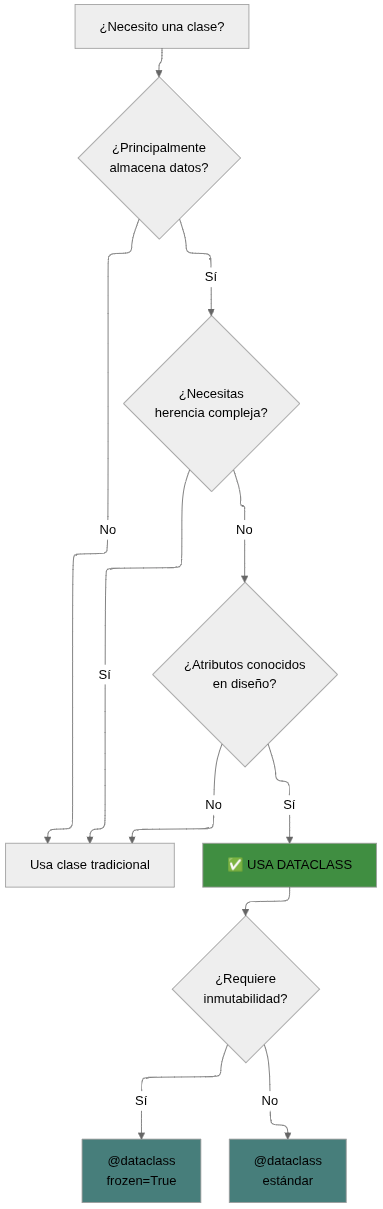






---

## 🔗 Recursos Adicionales



### Documentación oficial

- [Python Dataclasses Documentation](https://docs.python.org/3/library/dataclasses.html)
- [PEP 557 - Data Classes](https://peps.python.org/pep-0557/)



### Práctica en línea

- [Real Python - Data Classes](https://realpython.com/python-data-classes/)
- [GeeksforGeeks - Data Classes](https://www.geeksforgeeks.org/data-classes-in-python/)



## 📝 Resumen

| Concepto | Descripción |
| --- | --- |
| **@dataclass** | Decorador que automatiza la creación de clases de datos |
| **Type hints** | Obligatorios para definir atributos |
| **field()** | Función para personalizar atributos |
| **post_init** | Método para validaciones post-inicialización |
| **frozen=True** | Hace la instancia inmutable |
| **order=True** | Habilita comparaciones de orden |
| **asdict()/astuple()** | Conversión a diccionario/tupla |
